# ADS-B aircraft type identification (class balanced)

Copy of `adsb_transmitter_identification_rfsoc_kfold.ipynb`/`adsb_transmitter_identification_rfsoc_kfold_class_balanced.ipynb` with aircraft ICAO type (`icaotype`) as the target label. Combines every `data/*.npy` RFSoC capture and uses the decoded ICAO aircraft address to look up the type in `basic-ac-db.json` from `https://www.adsbexchange.com/data-products/sample-data/`. Records with no database match or no type are excluded. After pooling aircraft of the same type, the four types with the most records are selected and exactly 5,000 records are sampled without replacement from each (20,000 records total).

In [ ]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("pyModeS") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pyModeS<3"])


In [6]:
from pathlib import Path
import hashlib
import json
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyModeS as pms
import torch
import torch.nn as nn

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from torch.utils.data import DataLoader, Dataset

CONFIG = {
    "data_dir": Path("data"),
    "file_pattern": "*.npy",
    "aircraft_db_path": Path("basic-ac-db.json"),
    "num_classes": 4,
    "samples_per_class": 5000,
    "sample_rate_hz": 10e6,
    "samples_per_half_symbol": 5,
    "preamble_half_symbols": 16,
    "record_len": 1200,
    "preamble_len": 80,
    "payload_start": 80,
    "folds": 5,
    "seed": 42,
    "batch_size": 64,
    "epochs": 15,
    "learning_rate": 1e-3,
    "weight_decay": 2e-4,
    "dropout": 0.30,
    "cnn_channels": (16, 32, 48),
    "tcn_channels": 24,
    "gru_hidden": 32,
    "random_forest_trees": 200,
    "output_dir": Path("results/20261007_adsb_aircraft_type_mawson_lakes_class_balanced_4x5000"),
    "figure_dir": Path("results/20261007_adsb_aircraft_type_mawson_lakes_class_balanced_4x5000/figures"),
}
CONFIG["output_dir"].mkdir(parents=True, exist_ok=True)
CONFIG["figure_dir"].mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["seed"])
print("Device:", DEVICE)


Device: cpu


## Data


In [7]:
def find_capture_files(data_dir, pattern):
    files = sorted(path.resolve() for path in data_dir.glob(pattern) if path.is_file())
    if not files:
        raise FileNotFoundError(f"No {pattern} files found in {data_dir.resolve()}")
    return files


def decode_record(iq):
    if len(iq) != CONFIG["record_len"]:
        raise ValueError(f"Expected {CONFIG['record_len']} samples, found {len(iq)}")
    halves = np.abs(iq).reshape(-1, CONFIG["samples_per_half_symbol"]).mean(axis=1)
    payload = halves[CONFIG["preamble_half_symbols"]:]
    bits = payload[0::2] > payload[1::2]
    packed = np.packbits(bits).tobytes()
    message = packed.hex().upper()
    payload_hash = hashlib.sha256(packed).hexdigest()
    crc_valid = False
    icao = None
    try:
        crc_valid = int(pms.crc(message)) == 0
        if crc_valid:
            icao = str(pms.adsb.icao(message)).upper()
    except Exception:
        pass
    return icao, payload_hash, crc_valid


def load_capture(path, first_index):
    rows = []
    with path.open("rb") as stream:
        source_index = 0
        while stream.tell() < path.stat().st_size:
            timestamp = pd.Timestamp(np.load(stream, allow_pickle=True).item())
            iq = np.asarray(np.load(stream, allow_pickle=False))
            icao, payload_hash, crc_valid = decode_record(iq)
            preamble = np.asarray(iq[:CONFIG["preamble_len"]], dtype=np.complex64).copy()
            rows.append({
                "record_index": first_index + source_index,
                "source_record_index": source_index,
                "capture_file": path.name,
                "timestamp": timestamp,
                "capture_day": timestamp.strftime("%Y-%m-%d"),
                "sample_count": len(iq),
                "crc_valid": crc_valid,
                "icao": icao,
                "payload_hash": payload_hash,
                "preamble_hash": hashlib.sha256(preamble.tobytes()).hexdigest(),
                "preamble": preamble,
            })
            source_index += 1
    return pd.DataFrame(rows)


files = find_capture_files(CONFIG["data_dir"], CONFIG["file_pattern"])
frames = []
next_index = 0
for path in files:
    frame = load_capture(path, next_index)
    frames.append(frame)
    next_index += len(frame)
records = pd.concat(frames, ignore_index=True)
valid_records = records[records["crc_valid"]].copy()

capture_audit = records.groupby("capture_file", as_index=False).agg(
    total_records=("record_index", "size"),
    crc_valid_records=("crc_valid", "sum"),
    first_timestamp=("timestamp", "min"),
    last_timestamp=("timestamp", "max"),
    embedded_days=("capture_day", "nunique"),
)
file_day_counts = records.groupby(["capture_file", "capture_day"], as_index=False).agg(
    total_records=("record_index", "size"),
    crc_valid_records=("crc_valid", "sum"),
)
day_counts = records.groupby("capture_day", as_index=False).agg(
    total_records=("record_index", "size"),
    crc_valid_records=("crc_valid", "sum"),
    capture_files=("capture_file", "nunique"),
)



### Aircraft type labels

Map decoded ICAO addresses to `icaotype` using the local JSON Lines database. Pool records by type, rank types by available records, and select the top four with at least 5,000 records each. Sample exactly 5,000 records per type without replacement, allocating samples proportionally across capture days with a seeded random generator. Print the selected type/manufacturer/model mapping. Cross-day class coverage is computed by type.


In [8]:
def normalize_icao(value):
    if value is None:
        return None
    text = str(value).strip().upper()
    return text.zfill(6) if text else None


def database_text(value):
    if value is None:
        return None
    return str(value).strip() or None


def load_aircraft_database(path, captured_icaos):
    # basic-ac-db.json contains one JSON object per line (JSON Lines).
    # Keep only observed addresses so the full database is not held in memory.
    if not path.is_file():
        raise FileNotFoundError(f"Aircraft database not found: {path.resolve()}")
    rows = []
    with path.open(encoding="utf-8") as stream:
        for line_number, line in enumerate(stream, 1):
            if not line.strip():
                continue
            try:
                aircraft = json.loads(line)
            except json.JSONDecodeError as error:
                raise ValueError(f"Invalid JSON on line {line_number} of {path}") from error
            icao = normalize_icao(aircraft.get("icao"))
            if icao not in captured_icaos:
                continue
            icaotype = database_text(aircraft.get("icaotype"))
            rows.append({
                "icao": icao,
                "icaotype": None if icaotype is None else icaotype.upper(),
                "manufacturer": database_text(aircraft.get("manufacturer")),
                "model": database_text(aircraft.get("model")),
            })
    database = pd.DataFrame(rows, columns=["icao", "icaotype", "manufacturer", "model"])
    if database["icao"].duplicated().any():
        raise ValueError("Aircraft database contains duplicate ICAO addresses among captured aircraft")
    return database.set_index("icao")


valid_records["icao"] = valid_records["icao"].map(normalize_icao)
aircraft_database = load_aircraft_database(
    CONFIG["aircraft_db_path"], set(valid_records["icao"].dropna())
)
valid_records = valid_records.join(aircraft_database, on="icao", validate="many_to_one")
valid_records["type_mapping_status"] = np.select(
    [~valid_records["icao"].isin(aircraft_database.index), valid_records["icaotype"].isna()],
    ["icao_not_in_database", "icaotype_missing"],
    default="mapped",
)
valid_records[["manufacturer", "model"]] = valid_records[["manufacturer", "model"]].fillna("Unknown")

type_mapping_audit = valid_records.groupby("type_mapping_status", as_index=False).agg(
    records=("record_index", "size"),
    aircraft=("icao", "nunique"),
)
unmapped_aircraft = valid_records[valid_records["icaotype"].isna()].groupby(
    ["icao", "type_mapping_status"], dropna=False, as_index=False
).agg(records=("record_index", "size"), capture_files=("capture_file", "nunique"))
mapped_records = valid_records[valid_records["icaotype"].notna()].copy()
all_class_counts = mapped_records["icaotype"].value_counts().sort_index()
eligible_counts = all_class_counts[all_class_counts >= CONFIG["samples_per_class"]]
if CONFIG["num_classes"] < 2:
    raise ValueError("The experiment needs at least two ICAO type classes")
if len(eligible_counts) < CONFIG["num_classes"]:
    raise ValueError(
        f"Need {CONFIG['num_classes']} ICAO types with at least {CONFIG['samples_per_class']:,} records each; "
        f"found {len(eligible_counts)}. Check the captures, database mapping, and sampling settings."
    )
# all_class_counts is sorted by type, so equal counts are ranked by type name.
selected_icaotypes = eligible_counts.sort_values(ascending=False, kind="stable").head(
    CONFIG["num_classes"]
).index.tolist()
selected_type_records = mapped_records[mapped_records["icaotype"].isin(selected_icaotypes)]

# Match the reference notebook's proportional allocation across capture days.
# Largest remainders make the rounded quotas total exactly samples_per_class.
rng = np.random.default_rng(CONFIG["seed"])
sampled_frames = []
for icaotype, type_records in selected_type_records.groupby("icaotype"):
    day_sizes = type_records["capture_day"].value_counts().sort_index()
    quotas = CONFIG["samples_per_class"] * day_sizes / day_sizes.sum()
    day_samples = np.floor(quotas).astype(int)
    remainder = CONFIG["samples_per_class"] - int(day_samples.sum())
    extra_days = (quotas - day_samples).sort_values(ascending=False, kind="stable").index[:remainder]
    day_samples.loc[extra_days] += 1
    for day, day_records in type_records.groupby("capture_day"):
        sampled_frames.append(day_records.sample(n=int(day_samples.loc[day]), replace=False, random_state=rng))
selected = pd.concat(sampled_frames).sort_index().reset_index(drop=True)
retained_counts = selected["icaotype"].value_counts().sort_index()
class_names = sorted(retained_counts.index)
assert selected["icaotype"].nunique() == CONFIG["num_classes"]
assert retained_counts.eq(CONFIG["samples_per_class"]).all()
assert len(selected) == CONFIG["num_classes"] * CONFIG["samples_per_class"]
assert selected["record_index"].is_unique

type_selection_audit = all_class_counts.rename("available_records").to_frame()
type_selection_audit["eligible"] = type_selection_audit["available_records"].ge(CONFIG["samples_per_class"])
type_selection_audit["selected"] = type_selection_audit.index.isin(selected_icaotypes)
type_selection_audit["sampled_records"] = retained_counts.reindex(type_selection_audit.index, fill_value=0)
type_selection_audit = type_selection_audit.sort_values("available_records", ascending=False, kind="stable")
smallest_class = retained_counts.idxmin()
largest_class = retained_counts.idxmax()

type_counts = selected.groupby("icaotype").agg(
    records=("record_index", "size"), aircraft=("icao", "nunique")
).reindex(class_names)
type_file_counts = pd.crosstab(selected["icaotype"], selected["capture_file"]).reindex(class_names)
type_day_counts = pd.crosstab(selected["icaotype"], selected["capture_day"]).reindex(class_names)
days_per_type = (type_day_counts > 0).sum(axis=1)
selected["type_appears_multiple_days"] = selected["icaotype"].map(days_per_type.gt(1))
days_per_aircraft = selected.groupby("icao")["capture_day"].nunique()

# Preserve manufacturer/model pairings: a type can include several variants.
type_model_mapping = selected.groupby(
    ["icaotype", "manufacturer", "model"], as_index=False
).agg(aircraft=("icao", "nunique"), records=("record_index", "size")).sort_values(
    ["icaotype", "manufacturer", "model"]
).reset_index(drop=True)
type_model_mapping.insert(
    0, "class_index", type_model_mapping["icaotype"].map({name: i for i, name in enumerate(class_names)})
)

# Payload duplication is still audited per individual aircraft address.
payload_sizes = valid_records.groupby(["icao", "payload_hash"]).size().rename("copies")
repeated_payload_summary = pd.DataFrame([{
    "unique_payloads": int(len(payload_sizes)),
    "repeated_payload_groups": int((payload_sizes > 1).sum()),
    "records_in_repeated_groups": int(payload_sizes[payload_sizes > 1].sum()),
    "duplicate_copies_beyond_first": int((payload_sizes - 1).clip(lower=0).sum()),
    "largest_payload_multiplicity": int(payload_sizes.max()),
}])

display(capture_audit)
display(file_day_counts)
display(day_counts)
display(type_mapping_audit)
if not unmapped_aircraft.empty:
    print("Aircraft excluded because no ICAO type could be mapped:")
    display(unmapped_aircraft)
display(type_selection_audit)
display(type_counts.sort_values("records", ascending=False))
display(type_file_counts)
display(type_day_counts)
display(repeated_payload_summary)
print("Retained ICAO type -> manufacturer/model mapping (database values):")
print(type_model_mapping.to_string(index=False))
print(f"Files: {len(files)}")
print(f"Records: {len(records):,}; CRC-valid: {len(valid_records):,}")
print(f"Embedded calendar days: {records['capture_day'].nunique()}")
print(f"Decoded aircraft ICAO addresses: {valid_records['icao'].nunique()}")
print(f"Records with mapped types: {len(mapped_records):,}; excluded for missing type: {len(valid_records) - len(mapped_records):,}")
print(f"ICAO types: {len(all_class_counts)}; eligible for sampling: {len(eligible_counts)}; retained type classes: {len(class_names)}")
print("Selected types by available record count:", ", ".join(selected_icaotypes))
print(f"Balanced samples per type: {CONFIG['samples_per_class']:,}")
print(f"Mapped records outside the selected types: {len(mapped_records) - len(selected_type_records):,}")
print(f"Records removed by downsampling the selected types: {len(selected_type_records) - len(selected):,}")
print(f"Retained records: {len(selected):,}; retained aircraft: {selected['icao'].nunique()}")
print(f"Smallest retained type: {smallest_class} ({retained_counts.min():,})")
print(f"Largest retained type: {largest_class} ({retained_counts.max():,})")
print(f"Retained types seen on multiple days: {days_per_type.gt(1).sum():,}")


,capture_file,total_records,crc_valid_records,first_timestamp,last_timestamp,embedded_days
0,011026_ML.npy,4689,4689,2026-10-01 03:49:12.569538,2026-10-02 00:19:43.386036,2
1,021026_ML.npy,30977,30977,2026-10-02 01:43:06.469225,2026-10-06 02:17:56.888467,5
2,230926_ML_2.npy,1337,1337,2026-08-26 11:05:10.974228,2026-09-23 03:47:30.031488,2
3,230926_ML_3.npy,8551,8551,2026-09-23 04:43:09.476934,2026-09-24 00:01:23.105340,2
4,240926_ML.npy,49998,49998,2026-09-24 00:04:26.884473,2026-09-28 06:12:40.290379,5
5,280926_ML.npy,7364,7364,2026-09-28 07:12:29.819854,2026-09-29 02:07:49.723127,2
6,290926_ML.npy,8791,8791,2026-09-29 06:51:40.040063,2026-10-01 00:23:04.964902,3


,capture_file,capture_day,total_records,crc_valid_records
0,011026_ML.npy,2026-10-01,4218,4218
1,011026_ML.npy,2026-10-02,471,471
2,021026_ML.npy,2026-10-02,6674,6674
3,021026_ML.npy,2026-10-03,4823,4823
4,021026_ML.npy,2026-10-04,7396,7396
5,021026_ML.npy,2026-10-05,8589,8589
6,021026_ML.npy,2026-10-06,3495,3495
7,230926_ML_2.npy,2026-08-26,298,298
8,230926_ML_2.npy,2026-09-23,1039,1039
9,230926_ML_3.npy,2026-09-23,8494,8494


,capture_day,total_records,crc_valid_records,capture_files
0,2026-08-26,298,298,1
1,2026-09-23,9533,9533,2
2,2026-09-24,17422,17422,2
3,2026-09-25,16828,16828,1
4,2026-09-26,4996,4996,1
5,2026-09-27,4736,4736,1
6,2026-09-28,10111,10111,2
7,2026-09-29,5845,5845,2
8,2026-09-30,6219,6219,1
9,2026-10-01,4271,4271,2


,type_mapping_status,records,aircraft
0,icao_not_in_database,91,2
1,mapped,111616,280


Aircraft excluded because no ICAO type could be mapped:


...

,records,aircraft
icaotype,,
C172,5000,13
DA40,5000,30
DA42,5000,3
P28A,5000,4


capture_file,011026_ML.npy,021026_ML.npy,230926_ML_2.npy,230926_ML_3.npy,240926_ML.npy,280926_ML.npy,290926_ML.npy
icaotype,,,,,,,
C172,247,1265,98,374,2560,272,184
DA40,211,1443,57,356,2145,251,537
DA42,34,1440,34,737,2207,359,189
P28A,347,2084,154,404,1728,71,212


capture_day,2026-08-26,2026-09-23,2026-09-24,2026-09-25,2026-09-26,2026-09-27,2026-09-28,2026-09-29,2026-09-30,2026-10-01,2026-10-02,2026-10-03,2026-10-04,2026-10-05,2026-10-06
icaotype,,,,,,,,,,,,,,,
C172,0,472,696,935,335,438,302,172,138,228,165,336,293,285,205
DA40,25,380,783,735,104,149,487,294,385,190,294,92,405,502,175
DA42,15,756,1019,733,206,29,491,222,55,34,962,0,95,132,251
P28A,0,558,653,425,584,11,66,82,190,334,563,1059,172,303,0


,unique_payloads,repeated_payload_groups,records_in_repeated_groups,duplicate_copies_beyond_first,largest_payload_multiplicity
0,84467,2961,30201,27240,402


Retained ICAO type -> manufacturer/model mapping (database values):
 class_index icaotype                     manufacturer                model  aircraft  records
           0     C172          CESSNA AIRCRAFT COMPANY                 172M         1      196
           0     C172          CESSNA AIRCRAFT COMPANY                 172N         2     1476
           0     C172          CESSNA AIRCRAFT COMPANY                 172R         1       40
           0     C172          CESSNA AIRCRAFT COMPANY                 172S         6     3229
           0     C172          CESSNA AIRCRAFT COMPANY                R172K         3       59
           1     DA40 DIAMOND AIRCRAFT INDUSTRIES INC.                DA 40        29     4997
           1     DA40                          Unknown Diamond Star DA40 NG         1        3
           2     DA42      DIAMOND AIRCRAFT INDUSTRIES                DA 42         1     1527
           2     DA42 DIAMOND AIRCRAFT INDUSTRIES INC.                DA 42  

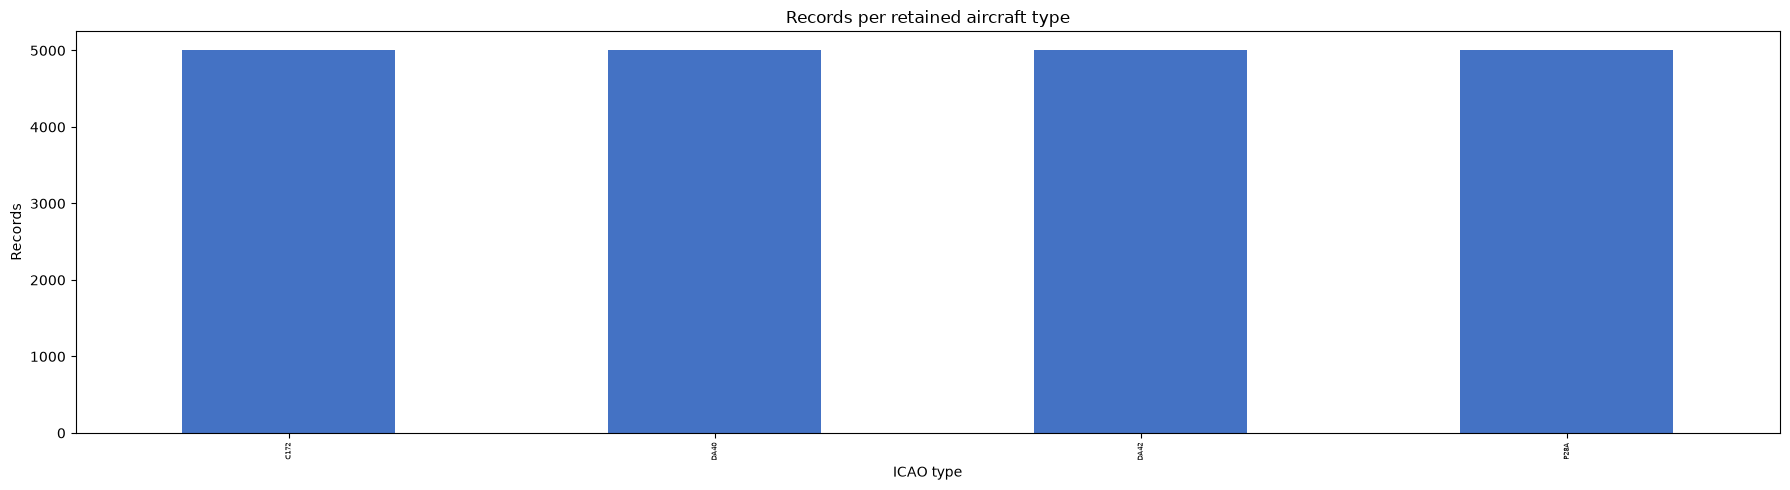

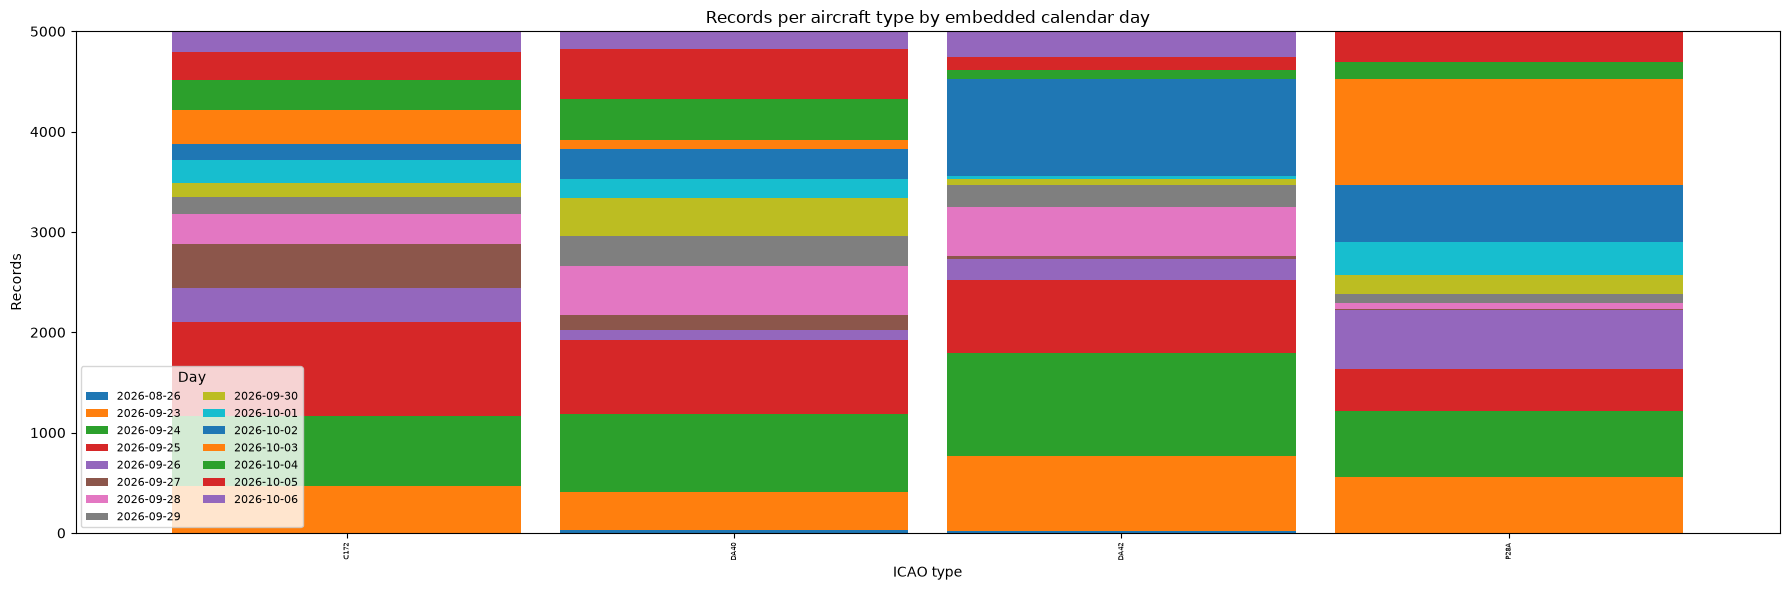

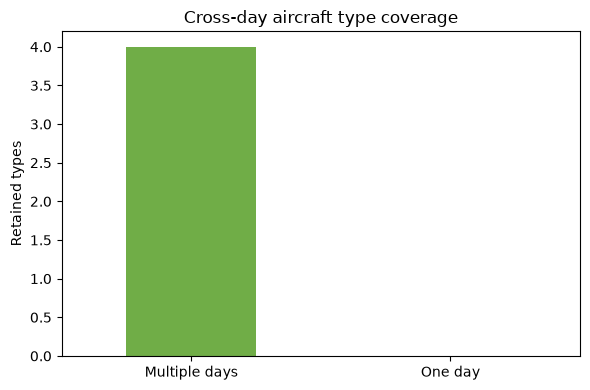

In [9]:
ordered = type_counts["records"].sort_values(ascending=False)

fig, axis = plt.subplots(figsize=(18, 5))
ordered.plot(kind="bar", ax=axis, color="#4472C4")
axis.set(title="Records per retained aircraft type", xlabel="ICAO type", ylabel="Records")
axis.tick_params(axis="x", labelsize=5)
fig.tight_layout()
fig.savefig(CONFIG["figure_dir"] / "records_per_icaotype.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axis = plt.subplots(figsize=(18, 6))
type_day_counts.loc[ordered.index].plot(kind="bar", stacked=True, ax=axis, width=0.9)
axis.set(title="Records per aircraft type by embedded calendar day", xlabel="ICAO type", ylabel="Records")
axis.tick_params(axis="x", labelsize=5)
axis.legend(title="Day", fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(CONFIG["figure_dir"] / "records_by_day.png", dpi=180, bbox_inches="tight")
plt.show()

overlap = pd.Series({
    "Multiple days": int(days_per_type.gt(1).sum()),
    "One day": int(days_per_type.eq(1).sum()),
})
fig, axis = plt.subplots(figsize=(6, 4))
overlap.plot(kind="bar", ax=axis, color=["#70AD47", "#A5A5A5"])
axis.set(title="Cross-day aircraft type coverage", xlabel="", ylabel="Retained types")
axis.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(CONFIG["figure_dir"] / "cross_day_overlap.png", dpi=180, bbox_inches="tight")
plt.show()


## Preamble inputs


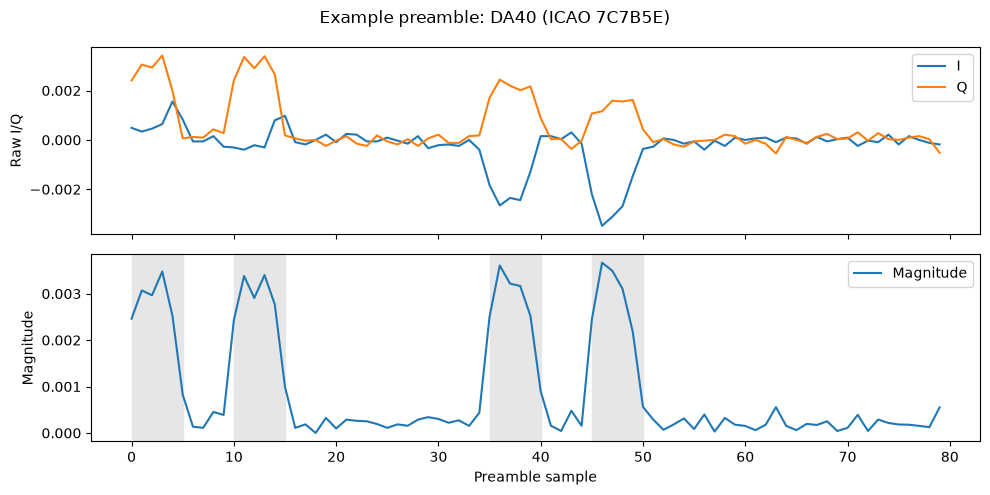

I/Q input: (20000, 2, 80)
Physical features: (20000, 33)
Input samples: 0--79; payload samples used: 0


In [10]:
PULSE_HALVES = np.zeros(CONFIG["preamble_half_symbols"], dtype=bool)
ACTIVE_HALF_INDICES = np.array([0, 2, 7, 9])
PULSE_HALVES[ACTIVE_HALF_INDICES] = True
ACTIVE_MASK = np.repeat(PULSE_HALVES, CONFIG["samples_per_half_symbol"])


def moment_features(values):
    values = np.asarray(values, dtype=np.float64)
    mean = values.mean()
    std = values.std() + 1e-12
    z = (values - mean) / std
    return mean, std, np.mean(z ** 3), np.mean(z ** 4)


def preamble_features(preamble):
    active = preamble[ACTIVE_MASK]
    quiet = preamble[~ACTIVE_MASK]
    pulses = np.stack([
        preamble[i * CONFIG["samples_per_half_symbol"]:(i + 1) * CONFIG["samples_per_half_symbol"]]
        for i in ACTIVE_HALF_INDICES
    ])
    amplitude = np.abs(active)
    values = list(moment_features(amplitude))
    phase_steps = np.angle(pulses[:, 1:] * np.conj(pulses[:, :-1])).ravel()
    mean_step = np.angle(np.mean(np.exp(1j * phase_steps)))
    centred_steps = np.angle(np.exp(1j * (phase_steps - mean_step)))
    i_power = np.mean(active.real ** 2) + 1e-12
    q_power = np.mean(active.imag ** 2) + 1e-12
    correlation = np.corrcoef(active.real, active.imag)[0, 1]
    correlation = correlation if np.isfinite(correlation) else 0.0
    prototype = pulses.mean(axis=0)
    pulse_power = np.mean(np.abs(pulses) ** 2, axis=1)
    values += [
        amplitude.max() / (np.sqrt(np.mean(amplitude ** 2)) + 1e-12),
        np.mean(amplitude ** 2),
        np.mean(np.abs(quiet) ** 2),
        10 * np.log10((np.mean(amplitude ** 2) + 1e-12) / (np.mean(np.abs(quiet) ** 2) + 1e-12)),
        mean_step * CONFIG["sample_rate_hz"] / (2 * np.pi),
        np.std(centred_steps),
        10 * np.log10(i_power / q_power),
        correlation,
        np.std(pulse_power) / (np.mean(pulse_power) + 1e-12),
    ]
    values += np.abs(pulses).mean(axis=0).tolist()
    values += prototype.real.tolist()
    values += prototype.imag.tolist()
    values += np.angle(prototype).tolist()
    return np.asarray(values, dtype=np.float32)


FEATURE_NAMES = [
    "amplitude_mean", "amplitude_std", "amplitude_skew", "amplitude_kurtosis",
    "crest_factor", "active_power", "quiet_power", "preamble_snr_db",
    "carrier_offset_hz", "phase_step_std", "iq_power_imbalance_db",
    "iq_correlation", "pulse_power_variation",
]
FEATURE_NAMES += [f"pulse_amplitude_{i}" for i in range(5)]
FEATURE_NAMES += [f"pulse_i_{i}" for i in range(5)]
FEATURE_NAMES += [f"pulse_q_{i}" for i in range(5)]
FEATURE_NAMES += [f"pulse_phase_{i}" for i in range(5)]

class_to_index = {name: index for index, name in enumerate(class_names)}
y = selected["icaotype"].map(class_to_index).to_numpy(dtype=np.int64)
raw_preambles = np.stack(selected["preamble"].to_numpy()).astype(np.complex64)
source_hashes = selected["preamble_hash"].to_numpy()
stored_hashes = np.array([hashlib.sha256(value.tobytes()).hexdigest() for value in raw_preambles])
assert np.array_equal(source_hashes, stored_hashes)

X_preamble = np.stack([raw_preambles.real, raw_preambles.imag], axis=1).astype(np.float32)
X_physical = np.stack([preamble_features(value) for value in raw_preambles])
model_metadata = selected[[
    "record_index", "source_record_index", "capture_file", "capture_day",
    "timestamp", "icao", "icaotype", "manufacturer", "model", "payload_hash", "type_appears_multiple_days",
]].copy()

assert X_preamble.shape[1:] == (2, 80)
assert X_physical.shape[1] == len(FEATURE_NAMES) == 33
assert CONFIG["preamble_len"] == CONFIG["payload_start"] == 80

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(X_preamble[0, 0], label="I")
axes[0].plot(X_preamble[0, 1], label="Q")
axes[0].set_ylabel("Raw I/Q")
axes[0].legend()
axes[1].plot(np.abs(raw_preambles[0]), label="Magnitude")
for start in ACTIVE_HALF_INDICES * CONFIG["samples_per_half_symbol"]:
    axes[1].axvspan(start, start + CONFIG["samples_per_half_symbol"], color="0.9")
axes[1].set(xlabel="Preamble sample", ylabel="Magnitude")
axes[1].legend()
fig.suptitle(f"Example preamble: {model_metadata.loc[0, 'icaotype']} (ICAO {model_metadata.loc[0, 'icao']})")
fig.tight_layout()
fig.savefig(CONFIG["figure_dir"] / "preamble_input.png", dpi=180, bbox_inches="tight")
plt.show()

records.drop(columns="preamble", inplace=True)
valid_records.drop(columns="preamble", inplace=True)
mapped_records.drop(columns="preamble", inplace=True)
selected.drop(columns="preamble", inplace=True)
print("I/Q input:", X_preamble.shape)
print("Physical features:", X_physical.shape)
print("Input samples: 0--79; payload samples used: 0")


## Five-fold split


,fold,training_records,validation_records,training_classes,validation_classes,training_aircraft,validation_aircraft,aircraft_icao_overlap,record_overlap,payload_hash_overlap
0,1,16000,4000,4,4,50,47,47,0,282
1,2,16000,4000,4,4,50,49,49,0,278
2,3,16000,4000,4,4,50,48,48,0,266
3,4,16000,4000,4,4,50,48,48,0,264
4,5,16000,4000,4,4,50,50,50,0,286


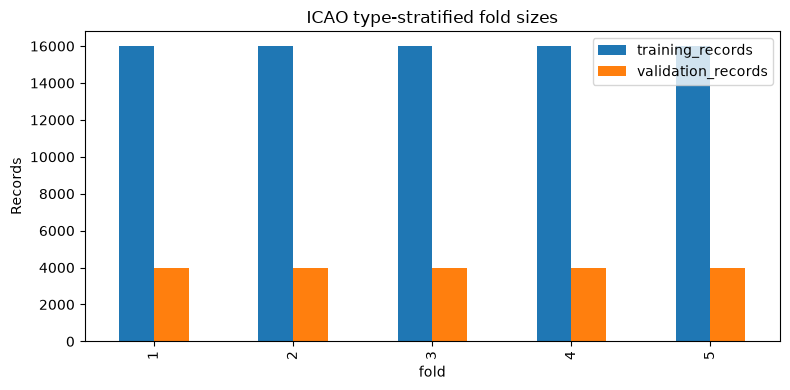

In [11]:
n_splits = min(CONFIG["folds"], int(retained_counts.min()))
if n_splits < 2:
    raise ValueError("Stratified K-fold evaluation needs at least two folds and two records per type")
splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=CONFIG["seed"])
folds = list(splitter.split(np.zeros(len(y)), y))

fold_rows = []
validation_count = np.zeros(len(y), dtype=int)
for fold_number, (train_index, val_index) in enumerate(folds, 1):
    validation_count[val_index] += 1
    train_hashes = set(model_metadata.loc[train_index, "payload_hash"])
    val_hashes = set(model_metadata.loc[val_index, "payload_hash"])
    assert set(train_index).isdisjoint(val_index)
    assert set(y[train_index]) == set(range(len(class_names)))
    assert set(y[val_index]) == set(range(len(class_names)))
    fold_rows.append({
        "fold": fold_number,
        "training_records": len(train_index),
        "validation_records": len(val_index),
        "training_classes": len(np.unique(y[train_index])),
        "validation_classes": len(np.unique(y[val_index])),
        "training_aircraft": model_metadata.loc[train_index, "icao"].nunique(),
        "validation_aircraft": model_metadata.loc[val_index, "icao"].nunique(),
        "aircraft_icao_overlap": len(
            set(model_metadata.loc[train_index, "icao"]) & set(model_metadata.loc[val_index, "icao"])
        ),
        "record_overlap": 0,
        "payload_hash_overlap": len(train_hashes & val_hashes),
    })
assert np.all(validation_count == 1)
fold_audit = pd.DataFrame(fold_rows)
display(fold_audit)

fig, axis = plt.subplots(figsize=(8, 4))
fold_audit.set_index("fold")[["training_records", "validation_records"]].plot(kind="bar", ax=axis)
axis.set(title="ICAO type-stratified fold sizes", ylabel="Records")
fig.tight_layout()
fig.savefig(CONFIG["figure_dir"] / "fold_sizes.png", dpi=180, bbox_inches="tight")
plt.show()


## Models


In [12]:
class ArrayDataset(Dataset):
    def __init__(self, values, labels=None):
        self.values = torch.as_tensor(values, dtype=torch.float32)
        self.labels = None if labels is None else torch.as_tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.values)

    def __getitem__(self, index):
        if self.labels is None:
            return self.values[index]
        return self.values[index], self.labels[index]


class PreambleCNN(nn.Module):
    def __init__(self, classes):
        super().__init__()
        c1, c2, c3 = CONFIG["cnn_channels"]
        self.network = nn.Sequential(
            nn.Conv1d(2, c1, 7, padding=3), nn.BatchNorm1d(c1), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(c1, c2, 5, padding=2), nn.BatchNorm1d(c2), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(c2, c3, 3, padding=1), nn.BatchNorm1d(c3), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Dropout(CONFIG["dropout"]),
            nn.Linear(c3, classes),
        )

    def forward(self, values):
        return self.network(values)


class TCNBlock(nn.Module):
    def __init__(self, channels, dilation):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, 3, padding=dilation, dilation=dilation),
            nn.BatchNorm1d(channels), nn.ReLU(), nn.Dropout(CONFIG["dropout"] / 2),
            nn.Conv1d(channels, channels, 3, padding=dilation, dilation=dilation),
            nn.BatchNorm1d(channels),
        )

    def forward(self, values):
        return torch.relu(values + self.block(values))


class PreambleTCN(nn.Module):
    def __init__(self, classes):
        super().__init__()
        channels = CONFIG["tcn_channels"]
        self.input_layer = nn.Conv1d(2, channels, 1)
        self.blocks = nn.Sequential(*(TCNBlock(channels, d) for d in (1, 2, 4)))
        self.output_layer = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.Dropout(CONFIG["dropout"]),
            nn.Linear(channels, classes),
        )

    def forward(self, values):
        return self.output_layer(self.blocks(self.input_layer(values)))


class PreambleGRU(nn.Module):
    def __init__(self, classes):
        super().__init__()
        self.gru = nn.GRU(2, CONFIG["gru_hidden"], batch_first=True, bidirectional=True)
        self.output_layer = nn.Sequential(
            nn.LayerNorm(2 * CONFIG["gru_hidden"]),
            nn.Dropout(CONFIG["dropout"]),
            nn.Linear(2 * CONFIG["gru_hidden"], classes),
        )

    def forward(self, values):
        _, hidden = self.gru(values.transpose(1, 2))
        return self.output_layer(torch.cat([hidden[-2], hidden[-1]], dim=1))


MODEL_NAMES = {
    "physical_feature_svm": "Physical-feature RBF SVM",
    "physical_feature_random_forest": "Physical-feature random forest",
    "preamble_cnn": "Compact 1D CNN",
    "preamble_tcn": "Compact TCN",
    "preamble_gru_rnn": "Compact bidirectional GRU",
}
MODEL_ORDER = list(MODEL_NAMES)


In [13]:
def loader(values, labels=None, shuffle=False):
    return DataLoader(
        ArrayDataset(values, labels), batch_size=CONFIG["batch_size"],
        shuffle=shuffle, num_workers=0, pin_memory=DEVICE == "cuda",
    )


def train_neural(model, train_values, train_labels, seed):
    set_seed(seed)
    model = model.to(DEVICE)
    counts = np.bincount(train_labels, minlength=len(class_names)).astype(np.float32)
    weights = counts.sum() / (len(class_names) * counts)
    criterion = nn.CrossEntropyLoss(weight=torch.tensor(weights, device=DEVICE))
    optimiser = torch.optim.AdamW(
        model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"]
    )
    history = []
    for _ in range(CONFIG["epochs"]):
        model.train()
        loss_sum = 0.0
        for batch, targets in loader(train_values, train_labels, shuffle=True):
            batch, targets = batch.to(DEVICE), targets.to(DEVICE)
            optimiser.zero_grad()
            loss = criterion(model(batch), targets)
            loss.backward()
            optimiser.step()
            loss_sum += loss.item() * len(targets)
        history.append(loss_sum / len(train_labels))
    return model, history, weights


@torch.no_grad()
def predict_neural(model, values):
    model.eval()
    return np.concatenate([
        torch.argmax(model(batch.to(DEVICE)), dim=1).cpu().numpy()
        for batch in loader(values)
    ])


def scores(targets, predictions):
    return {
        "accuracy": accuracy_score(targets, predictions),
        "balanced_accuracy": balanced_accuracy_score(targets, predictions),
        "macro_f1": f1_score(targets, predictions, average="macro", zero_division=0),
    }


def svm_size_bytes(model):
    scaler = model.named_steps["standardscaler"]
    svc = model.named_steps["svc"]
    arrays = [scaler.mean_, scaler.scale_, svc.support_vectors_, svc.dual_coef_, svc.intercept_, svc.support_]
    return sum(value.nbytes for value in arrays)


def forest_size_bytes(model):
    attributes = ["children_left", "children_right", "feature", "threshold", "value", "impurity", "n_node_samples"]
    return sum(
        getattr(tree.tree_, name).nbytes
        for tree in model.estimators_
        for name in attributes
    )


## Train and evaluate


In [14]:
fold_results = []
prediction_rows = []
model_size_rows = []
importance_rows = []
preprocessing_rows = []
training_histories = {}

for fold_number, (train_index, val_index) in enumerate(folds, 1):
    print(f"Fold {fold_number}/{n_splits}")
    channel_mean = X_preamble[train_index].mean(axis=(0, 2), keepdims=True)
    channel_std = X_preamble[train_index].std(axis=(0, 2), keepdims=True) + 1e-6
    scaled_train = (X_preamble[train_index] - channel_mean) / channel_std
    scaled_validation = (X_preamble[val_index] - channel_mean) / channel_std
    train_counts = np.bincount(y[train_index], minlength=len(class_names)).astype(np.float32)
    train_weights = train_counts.sum() / (len(class_names) * train_counts)
    preprocessing_rows.append({
        "fold": fold_number,
        "training_records": len(train_index),
        "validation_records": len(val_index),
        "iq_mean_i": float(channel_mean[0, 0, 0]),
        "iq_mean_q": float(channel_mean[0, 1, 0]),
        "iq_std_i": float(channel_std[0, 0, 0]),
        "iq_std_q": float(channel_std[0, 1, 0]),
        "class_weight_min": float(train_weights.min()),
        "class_weight_max": float(train_weights.max()),
        "fit_scope": "training fold only",
    })

    for model_number, experiment in enumerate(MODEL_ORDER):
        seed = CONFIG["seed"] + 100 * fold_number + model_number
        started = time.perf_counter()

        if experiment == "physical_feature_svm":
            model = make_pipeline(
                StandardScaler(),
                SVC(C=3.0, kernel="rbf", gamma="scale", class_weight="balanced"),
            )
            model.fit(X_physical[train_index], y[train_index])
            predictions = model.predict(X_physical[val_index])
            parameters = np.nan
            support_vectors = model.named_steps["svc"].support_vectors_.shape[0]
            tree_nodes = np.nan
            fitted_size_mb = svm_size_bytes(model) / 1e6

        elif experiment == "physical_feature_random_forest":
            model = RandomForestClassifier(
                n_estimators=CONFIG["random_forest_trees"], min_samples_leaf=2,
                max_features="sqrt", class_weight="balanced_subsample",
                n_jobs=-1, random_state=seed,
            )
            model.fit(X_physical[train_index], y[train_index])
            predictions = model.predict(X_physical[val_index])
            for name, importance in zip(FEATURE_NAMES, model.feature_importances_):
                importance_rows.append({"fold": fold_number, "feature": name, "importance": importance})
            parameters = np.nan
            support_vectors = np.nan
            tree_nodes = sum(tree.tree_.node_count for tree in model.estimators_)
            fitted_size_mb = forest_size_bytes(model) / 1e6

        else:
            model_class = {
                "preamble_cnn": PreambleCNN,
                "preamble_tcn": PreambleTCN,
                "preamble_gru_rnn": PreambleGRU,
            }[experiment]
            model = model_class(len(class_names))
            model, history, neural_weights = train_neural(model, scaled_train, y[train_index], seed)
            assert np.allclose(neural_weights, train_weights)
            predictions = predict_neural(model, scaled_validation)
            parameters = sum(parameter.numel() for parameter in model.parameters())
            support_vectors = np.nan
            tree_nodes = np.nan
            fitted_size_mb = parameters * 4 / 1e6
            training_histories[(experiment, fold_number)] = history

        metrics = scores(y[val_index], predictions)
        fold_results.append({
            "experiment": experiment,
            "model": MODEL_NAMES[experiment],
            "fold": fold_number,
            "n_train": len(train_index),
            "n_validation": len(val_index),
            **metrics,
        })
        model_size_rows.append({
            "experiment": experiment,
            "fold": fold_number,
            "parameters": parameters,
            "support_vectors": support_vectors,
            "tree_nodes": tree_nodes,
            "estimated_size_mb": fitted_size_mb,
            "training_seconds": time.perf_counter() - started,
        })
        for position, target, prediction in zip(val_index, y[val_index], predictions):
            meta = model_metadata.loc[position]
            prediction_rows.append({
                "experiment": experiment,
                "fold": fold_number,
                "record_index": int(meta["record_index"]),
                "capture_file": meta["capture_file"],
                "capture_day": meta["capture_day"],
                "icao": meta["icao"],
                "type_appears_multiple_days": bool(meta["type_appears_multiple_days"]),
                "true_class": class_names[int(target)],
                "predicted_class": class_names[int(prediction)],
            })
        print(f"  {MODEL_NAMES[experiment]:32s} balanced={metrics['balanced_accuracy']:.3f}")

fold_results = pd.DataFrame(fold_results)
predictions = pd.DataFrame(prediction_rows)
model_sizes = pd.DataFrame(model_size_rows)
feature_importance = pd.DataFrame(importance_rows)
preprocessing_audit = pd.DataFrame(preprocessing_rows)


Fold 1/5
  Physical-feature RBF SVM         balanced=0.585
  Physical-feature random forest   balanced=0.565
  Compact 1D CNN                   balanced=0.569
  Compact TCN                      balanced=0.558
  Compact bidirectional GRU        balanced=0.630
Fold 2/5
  Physical-feature RBF SVM         balanced=0.581
  Physical-feature random forest   balanced=0.568
  Compact 1D CNN                   balanced=0.590
  Compact TCN                      balanced=0.584
  Compact bidirectional GRU        balanced=0.645
Fold 3/5
  Physical-feature RBF SVM         balanced=0.575
  Physical-feature random forest   balanced=0.562
  Compact 1D CNN                   balanced=0.577
  Compact TCN                      balanced=0.587
  Compact bidirectional GRU        balanced=0.609
Fold 4/5
  Physical-feature RBF SVM         balanced=0.578
  Physical-feature random forest   balanced=0.565
  Compact 1D CNN                   balanced=0.585
  Compact TCN                      balanced=0.571
  Compact bidi

In [15]:
aggregate_rows = []
class_recall_rows = []
for experiment in MODEL_ORDER:
    subset = predictions[predictions["experiment"] == experiment]
    per_fold = fold_results[fold_results["experiment"] == experiment]
    matrix = confusion_matrix(
        subset["true_class"], subset["predicted_class"], labels=class_names, normalize="true"
    )
    recalls = np.diag(matrix)
    for class_name, recall in zip(class_names, recalls):
        class_recall_rows.append({
            "experiment": experiment,
            "icaotype": class_name,
            "aircraft": int(type_counts.loc[class_name, "aircraft"]),
            "records": int(retained_counts[class_name]),
            "days": int(days_per_type[class_name]),
            "recall": recall,
        })
    overall = scores(subset["true_class"], subset["predicted_class"])
    sizes = model_sizes[model_sizes["experiment"] == experiment]
    aggregate_rows.append({
        "experiment": experiment,
        "model": MODEL_NAMES[experiment],
        "oof_accuracy": overall["accuracy"],
        "oof_balanced_accuracy": overall["balanced_accuracy"],
        "oof_macro_f1": overall["macro_f1"],
        "fold_accuracy_mean": per_fold["accuracy"].mean(),
        "fold_accuracy_std": per_fold["accuracy"].std(ddof=1),
        "fold_balanced_accuracy_mean": per_fold["balanced_accuracy"].mean(),
        "fold_balanced_accuracy_std": per_fold["balanced_accuracy"].std(ddof=1),
        "fold_macro_f1_mean": per_fold["macro_f1"].mean(),
        "fold_macro_f1_std": per_fold["macro_f1"].std(ddof=1),
        "parameters": sizes["parameters"].dropna().mean(),
        "support_vectors_mean": sizes["support_vectors"].dropna().mean(),
        "tree_nodes_mean": sizes["tree_nodes"].dropna().mean(),
        "estimated_size_mb_mean": sizes["estimated_size_mb"].mean(),
    })

aggregate_results = pd.DataFrame(aggregate_rows).sort_values(
    ["oof_balanced_accuracy", "oof_macro_f1"], ascending=False
).reset_index(drop=True)
class_recall = pd.DataFrame(class_recall_rows)
best_experiment = aggregate_results.loc[0, "experiment"]
best_model = aggregate_results.loc[0, "model"]

cross_day_rows = []
for experiment in MODEL_ORDER:
    subset = predictions[predictions["experiment"] == experiment]
    for flag, label in [(True, "multiple days"), (False, "one day")]:
        part = subset[subset["type_appears_multiple_days"] == flag]
        if part.empty:
            continue
        cross_day_rows.append({
            "experiment": experiment,
            "type_day_group": label,
            "classes": part["true_class"].nunique(),
            "records": len(part),
            **scores(part["true_class"], part["predicted_class"]),
        })
cross_day_results = pd.DataFrame(cross_day_rows)

display(aggregate_results)
display(fold_results.groupby("model")[["accuracy", "balanced_accuracy", "macro_f1"]].agg(["mean", "std"]))
display(cross_day_results[cross_day_results["experiment"] == best_experiment])
print("Best model by balanced accuracy:", best_model)


,experiment,model,oof_accuracy,oof_balanced_accuracy,oof_macro_f1,fold_accuracy_mean,fold_accuracy_std,fold_balanced_accuracy_mean,fold_balanced_accuracy_std,fold_macro_f1_mean,fold_macro_f1_std,parameters,support_vectors_mean,tree_nodes_mean,estimated_size_mb_mean
0,preamble_gru_rnn,Compact bidirectional GRU,0.62820,0.62820,0.646366,0.62820,0.012916,0.62820,0.012916,0.646237,0.011437,7300.0,NaN,NaN,0.029200
1,preamble_cnn,Compact 1D CNN,0.58020,0.58020,0.589708,0.58020,0.007956,0.58020,0.007956,0.586804,0.011791,7876.0,NaN,NaN,0.031504
2,physical_feature_svm,Physical-feature RBF SVM,0.57910,0.57910,0.588712,0.57910,0.004068,0.57910,0.004068,0.588648,0.004145,NaN,12141.6,NaN,3.545923
3,preamble_tcn,Compact TCN,0.57600,0.57600,0.568958,0.57600,0.011911,0.57600,0.011911,0.566083,0.019251,10972.0,NaN,NaN,0.043888
4,physical_feature_random_forest,Physical-feature random forest,0.56665,0.56665,0.576953,0.56665,0.004588,0.56665,0.004588,0.576929,0.004538,NaN,NaN,1016099.2,81.287936


accuracy           balanced_accuracy            \
                                   mean       std              mean       std   
model                                                                           
Compact 1D CNN                  0.58020  0.007956           0.58020  0.007956   
Compact TCN                     0.57600  0.011911           0.57600  0.011911   
Compact bidirectional GRU       0.62820  0.012916           0.62820  0.012916   
Physical-feature RBF SVM        0.57910  0.004068           0.57910  0.004068   
Physical-feature random forest  0.56665  0.004588           0.56665  0.004588   

                                macro_f1            
                                    mean       std  
model                                               
Compact 1D CNN                  0.586804  0.011791  
Compact TCN                     0.566083  0.019251  
Compact bidirectional GRU       0.646237  0.011437  
Physical-feature RBF SVM        0.588648  0.004145  
Physical-feature random forest  0.576929  0.004538

,experiment,type_day_group,classes,records,accuracy,balanced_accuracy,macro_f1
4,preamble_gru_rnn,multiple days,4,20000,0.6282,0.6282,0.646366


Best model by balanced accuracy: Compact bidirectional GRU


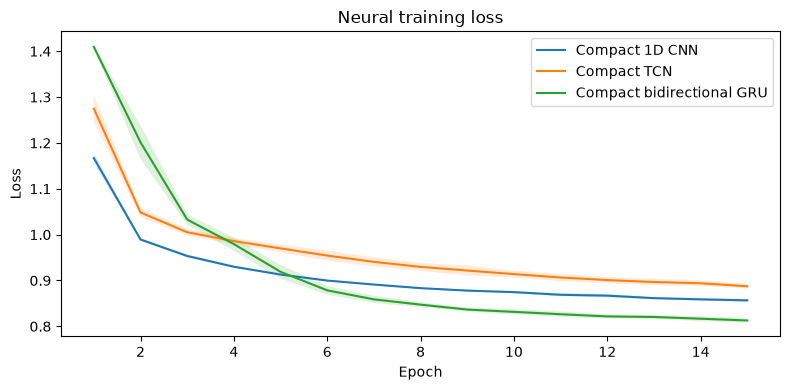

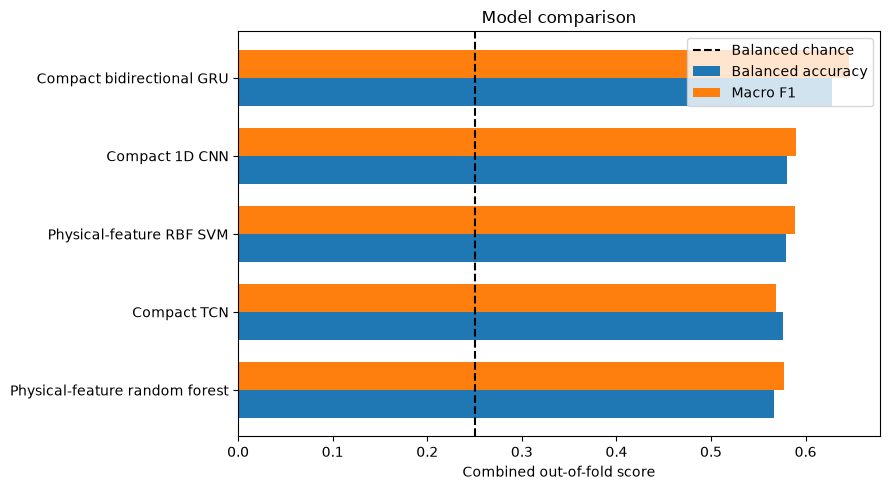

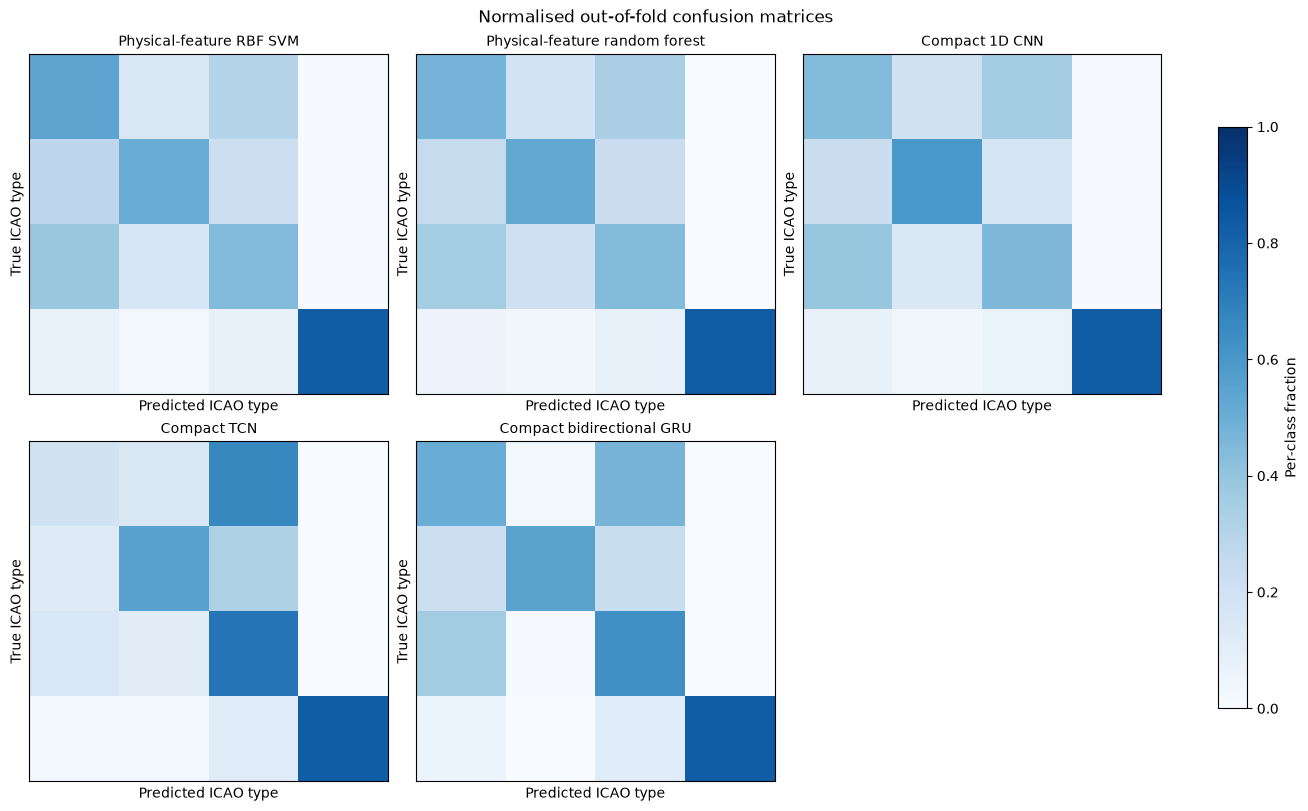

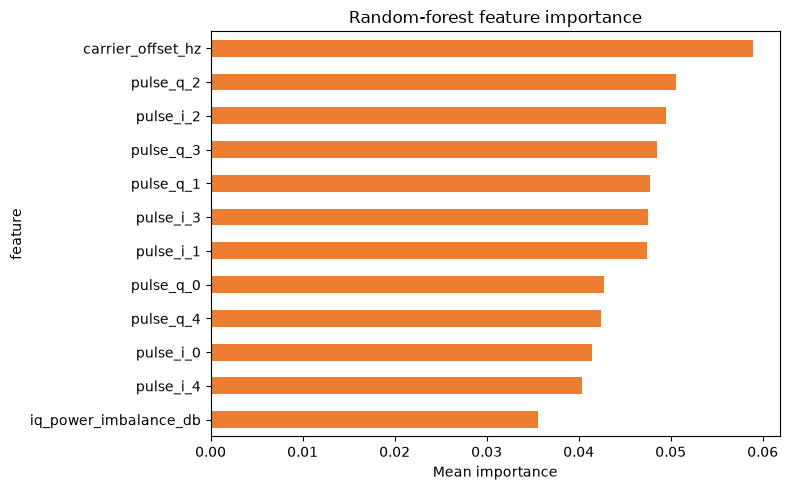

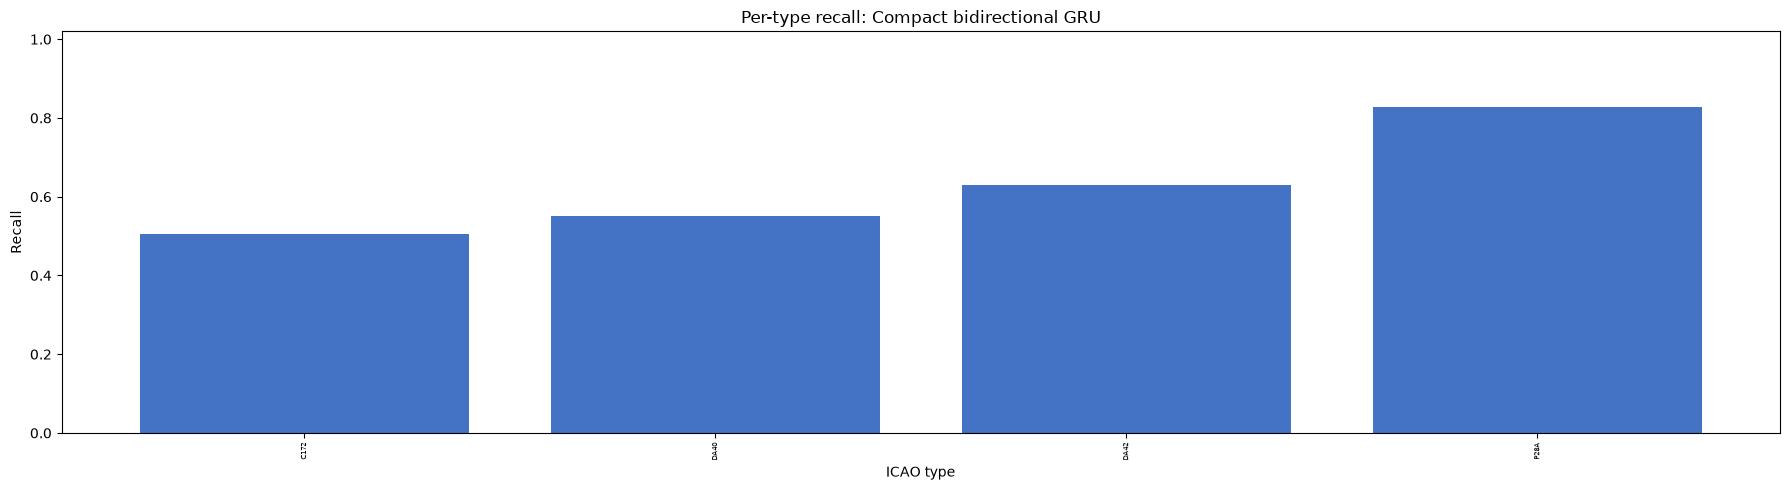

In [16]:
neural_models = ["preamble_cnn", "preamble_tcn", "preamble_gru_rnn"]
epochs = np.arange(1, CONFIG["epochs"] + 1)
fig, axis = plt.subplots(figsize=(8, 4))
for experiment in neural_models:
    histories = np.stack([training_histories[(experiment, fold)] for fold in range(1, n_splits + 1)])
    mean = histories.mean(axis=0)
    std = histories.std(axis=0)
    axis.plot(epochs, mean, label=MODEL_NAMES[experiment])
    axis.fill_between(epochs, mean - std, mean + std, alpha=0.15)
axis.set(title="Neural training loss", xlabel="Epoch", ylabel="Loss")
axis.legend()
fig.tight_layout()
fig.savefig(CONFIG["figure_dir"] / "training_loss.png", dpi=180, bbox_inches="tight")
plt.show()

plot_data = aggregate_results.sort_values("oof_balanced_accuracy")
positions = np.arange(len(plot_data))
fig, axis = plt.subplots(figsize=(9, 5))
axis.barh(positions - 0.18, plot_data["oof_balanced_accuracy"], 0.36, label="Balanced accuracy")
axis.barh(positions + 0.18, plot_data["oof_macro_f1"], 0.36, label="Macro F1")
axis.axvline(1 / len(class_names), color="black", linestyle="--", label="Balanced chance")
axis.set_yticks(positions, plot_data["model"])
axis.set(title="Model comparison", xlabel="Combined out-of-fold score")
axis.legend()
fig.tight_layout()
fig.savefig(CONFIG["figure_dir"] / "model_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(13, 8), constrained_layout=True)
for axis, experiment in zip(axes.ravel(), MODEL_ORDER):
    subset = predictions[predictions["experiment"] == experiment]
    matrix = confusion_matrix(
        subset["true_class"], subset["predicted_class"], labels=class_names, normalize="true"
    )
    image = axis.imshow(matrix, vmin=0, vmax=1, aspect="auto", cmap="Blues")
    axis.set_title(MODEL_NAMES[experiment], fontsize=10)
    axis.set(xlabel="Predicted ICAO type", ylabel="True ICAO type")
    axis.set_xticks([])
    axis.set_yticks([])
axes.ravel()[-1].axis("off")
fig.colorbar(image, ax=axes.ravel()[:5].tolist(), label="Per-class fraction", shrink=0.8)
fig.suptitle("Normalised out-of-fold confusion matrices")
fig.savefig(CONFIG["figure_dir"] / "confusion_matrices.png", dpi=180, bbox_inches="tight")
plt.show()

importance = feature_importance.groupby("feature")["importance"].mean().nlargest(12).sort_values()
fig, axis = plt.subplots(figsize=(8, 5))
importance.plot(kind="barh", ax=axis, color="#ED7D31")
axis.set(title="Random-forest feature importance", xlabel="Mean importance")
fig.tight_layout()
fig.savefig(CONFIG["figure_dir"] / "feature_importance.png", dpi=180, bbox_inches="tight")
plt.show()

best_recall = class_recall[class_recall["experiment"] == best_experiment].sort_values("recall")
fig, axis = plt.subplots(figsize=(18, 5))
axis.bar(best_recall["icaotype"], best_recall["recall"], color="#4472C4")
axis.set(title=f"Per-type recall: {best_model}", xlabel="ICAO type", ylabel="Recall", ylim=(0, 1.02))
axis.tick_params(axis="x", rotation=90, labelsize=5)
fig.tight_layout()
fig.savefig(CONFIG["figure_dir"] / "per_class_recall.png", dpi=180, bbox_inches="tight")
plt.show()


## Save


In [17]:
output_dir = CONFIG["output_dir"]
aggregate_results.to_csv(output_dir / "aggregate_results.csv", index=False)
fold_results.to_csv(output_dir / "fold_results.csv", index=False)
predictions.to_csv(output_dir / "out_of_fold_predictions.csv", index=False)
fold_audit.to_csv(output_dir / "fold_audit.csv", index=False)
model_sizes.to_csv(output_dir / "model_sizes_by_fold.csv", index=False)
feature_importance.to_csv(output_dir / "random_forest_feature_importance.csv", index=False)
class_recall.to_csv(output_dir / "per_class_recall.csv", index=False)
cross_day_results.to_csv(output_dir / "cross_day_performance.csv", index=False)
preprocessing_audit.to_csv(output_dir / "preprocessing_audit.csv", index=False)
capture_audit.to_csv(output_dir / "capture_file_audit.csv", index=False)
file_day_counts.to_csv(output_dir / "capture_file_day_counts.csv", index=False)
day_counts.to_csv(output_dir / "day_counts.csv", index=False)
type_counts.to_csv(output_dir / "icaotype_counts.csv")
type_selection_audit.to_csv(output_dir / "icaotype_selection_audit.csv")
type_file_counts.to_csv(output_dir / "icaotype_file_counts.csv")
type_day_counts.to_csv(output_dir / "icaotype_day_counts.csv")
type_model_mapping.to_csv(output_dir / "icaotype_manufacturer_model_mapping.csv", index=False)
type_mapping_audit.to_csv(output_dir / "type_mapping_audit.csv", index=False)
unmapped_aircraft.to_csv(output_dir / "unmapped_aircraft.csv", index=False)
aircraft_database.to_csv(output_dir / "captured_aircraft_database.csv")
repeated_payload_summary.to_csv(output_dir / "repeated_payload_summary.csv", index=False)

assignments = model_metadata.copy()
assignments["validation_fold"] = -1
for fold_number, (_, val_index) in enumerate(folds, 1):
    assignments.loc[val_index, "validation_fold"] = fold_number
assignments.to_csv(output_dir / "fold_assignments.csv", index=False)

model_input_audit = pd.DataFrame([{
    "representation": "physical features", "shape": "33",
    "source_samples": "0-79", "payload_samples": 0,
    "capture_hash_verified": True,
}, {
    "representation": "I/Q sequence", "shape": "2x80",
    "source_samples": "0-79", "payload_samples": 0,
    "capture_hash_verified": True,
}])
model_input_audit.to_csv(output_dir / "model_input_audit.csv", index=False)

summary = {
    "capture_files": [path.name for path in files],
    "total_records": int(len(records)),
    "crc_valid_records": int(len(valid_records)),
    "embedded_calendar_days": sorted(records["capture_day"].unique()),
    "target_label": "icaotype",
    "aircraft_database": str(CONFIG["aircraft_db_path"]),
    "total_aircraft_icao_addresses": int(valid_records["icao"].nunique()),
    "total_icaotype_classes": int(len(all_class_counts)),
    "records_with_mapped_types": int(len(mapped_records)),
    "records_excluded_missing_type": int(len(valid_records) - len(mapped_records)),
    "num_classes": CONFIG["num_classes"],
    "samples_per_class": CONFIG["samples_per_class"],
    "selected_icaotypes_by_available_count": selected_icaotypes,
    "eligible_type_classes": int(len(eligible_counts)),
    "records_excluded_below_sampling_threshold": int(all_class_counts[all_class_counts < CONFIG["samples_per_class"]].sum()),
    "records_excluded_other_eligible_types": int(eligible_counts[~eligible_counts.index.isin(selected_icaotypes)].sum()),
    "records_excluded_downsampling": int(len(selected_type_records) - len(selected)),
    "sampling": "without replacement; proportional by capture day",
    "class_names": class_names,
    "class_to_index": class_to_index,
    "retained_classes": int(len(class_names)),
    "retained_records": int(len(selected)),
    "smallest_retained_class": smallest_class,
    "smallest_retained_count": int(retained_counts.min()),
    "largest_retained_class": largest_class,
    "largest_retained_count": int(retained_counts.max()),
    "retained_aircraft": int(selected["icao"].nunique()),
    "types_on_multiple_days": int(days_per_type.gt(1).sum()),
    "aircraft_on_multiple_days": int(days_per_aircraft.gt(1).sum()),
    "split_unit": "record",
    "stratify_by": "icaotype",
    "folds": int(n_splits),
    "best_model": best_model,
}
with (output_dir / "dataset_summary.json").open("w") as stream:
    json.dump(summary, stream, indent=2)
with (output_dir / "experiment_config.json").open("w") as stream:
    json.dump({key: str(value) if isinstance(value, Path) else value for key, value in CONFIG.items()}, stream, indent=2)

expected_files = {path.name for path in CONFIG["data_dir"].glob(CONFIG["file_pattern"])}
assert expected_files == set(capture_audit["capture_file"])
assert selected["icaotype"].notna().all()
assert selected["icao"].notna().all()
assert selected["record_index"].is_unique
assert len(class_names) == CONFIG["num_classes"]
assert retained_counts.eq(CONFIG["samples_per_class"]).all()
assert len(selected) == CONFIG["num_classes"] * CONFIG["samples_per_class"]
assert set(class_names) == set(selected["icaotype"]) == set(type_model_mapping["icaotype"])
assert np.array_equal(y, model_metadata["icaotype"].map(class_to_index).to_numpy())
assert model_input_audit["payload_samples"].eq(0).all()
assert fold_audit["record_overlap"].eq(0).all()
assert preprocessing_audit["fit_scope"].eq("training fold only").all()
for experiment in MODEL_ORDER:
    subset = predictions[predictions["experiment"] == experiment]
    assert set(subset["true_class"]) == set(class_names)
    assert set(subset["predicted_class"]).issubset(class_names)
    assert len(subset) == len(selected)
    assert subset["record_index"].nunique() == len(selected)
print("Saved:", output_dir.resolve())
print("Verification passed")


Saved: /Users/calebrodgers/Desktop/ml/An-Investigation-on-Spectrum-Awareness-using-UltraScale-RFSoC-Technology/analysis/notebooks/results/20261007_adsb_aircraft_type_mawson_lakes_class_balanced_4x5000
Verification passed
